<a href="https://colab.research.google.com/github/Rajeraghav/AI-Engineer-Journey/blob/main/Day12/Customer%20Churn%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Please upload BOTH training and testing CSV files.


Saving customer_churn_dataset-training-master.csv to customer_churn_dataset-training-master (1).csv
Saving customer_churn_dataset-testing-master.csv to customer_churn_dataset-testing-master (1).csv

Uploaded files:
 - customer_churn_dataset-training-master (1).csv
 - customer_churn_dataset-testing-master (1).csv

Training file: customer_churn_dataset-training-master (1).csv
Testing file : customer_churn_dataset-testing-master (1).csv

Training Shape: (440833, 12)
Testing Shape : (64374, 12)

Training Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Testing Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage Frequency', 'Support Calls', 'Payment Delay', 'Subscription Type', 'Contract Length', 'Total Spend', 'Last Interaction', 'Churn']

Cleaned Columns:
['CustomerID', 'Age', 'Gender', 'Tenure', 'Usage_Frequency', 'Support_Calls', 'Payment_Dela

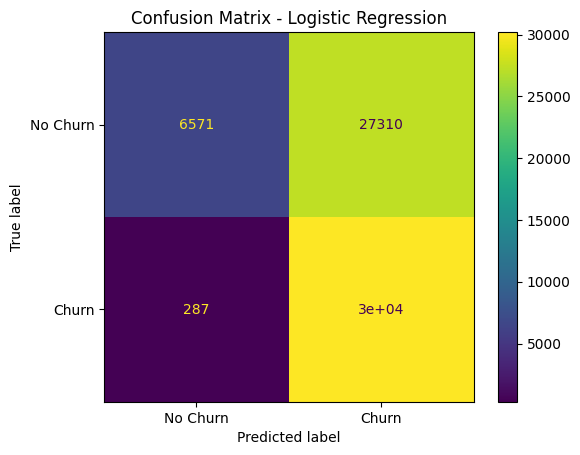


Random Forest
Confusion Matrix:
[[ 2175 31706]
 [   47 30446]]


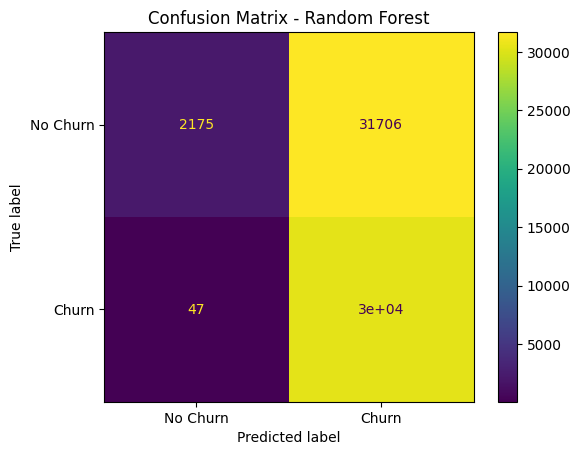


XGBoost
Confusion Matrix:
[[ 1968 31913]
 [   49 30444]]


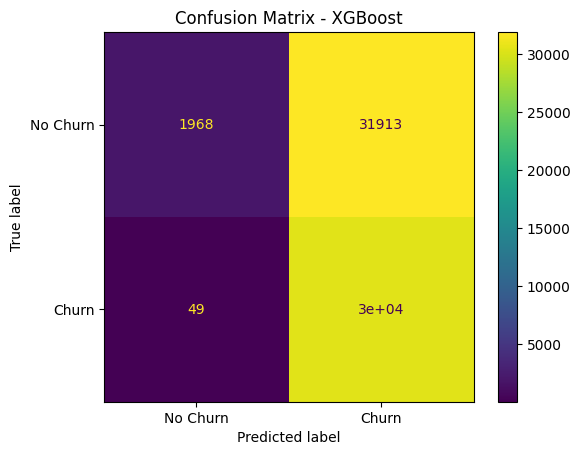

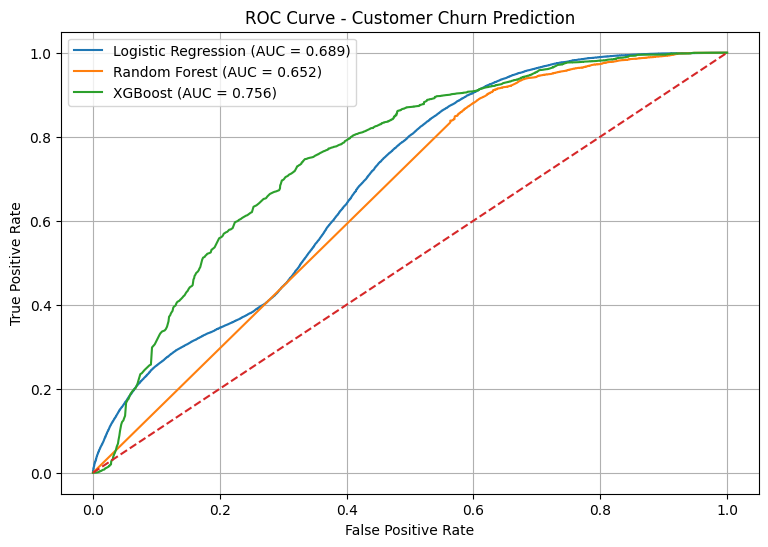


TOP 15 RANDOM FOREST FEATURES
                        Feature  Importance
             num__Support_Calls    0.294205
               num__Total_Spend    0.203576
                       num__Age    0.131909
             num__Payment_Delay    0.128188
   cat__Contract_Length_Monthly    0.109803
          num__Last_Interaction    0.052116
    cat__Contract_Length_Annual    0.021367
 cat__Contract_Length_Quarterly    0.018025
             cat__Gender_Female    0.015604
               cat__Gender_Male    0.013288
                    num__Tenure    0.008012
           num__Usage_Frequency    0.002669
   cat__Subscription_Type_Basic    0.000715
cat__Subscription_Type_Standard    0.000279
 cat__Subscription_Type_Premium    0.000244


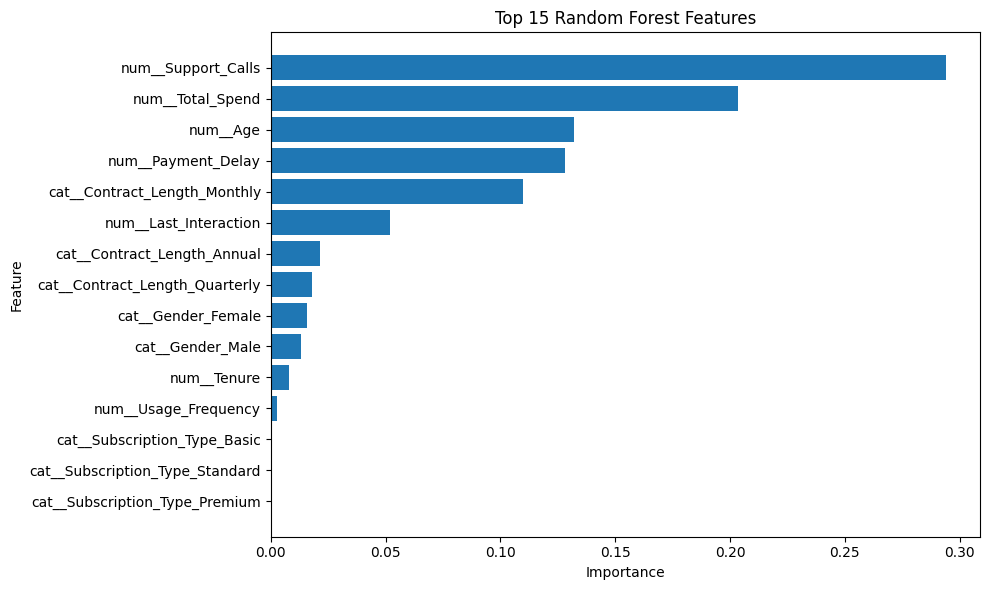


TOP 15 XGBOOST FEATURES
                        Feature  Importance
               num__Total_Spend    0.218083
             num__Support_Calls    0.201328
   cat__Contract_Length_Monthly    0.150757
             num__Payment_Delay    0.141515
             cat__Gender_Female    0.082563
               cat__Gender_Male    0.072887
                       num__Age    0.069182
          num__Last_Interaction    0.027074
                    num__Tenure    0.013247
   cat__Subscription_Type_Basic    0.011977
           num__Usage_Frequency    0.005337
 cat__Subscription_Type_Premium    0.003223
cat__Subscription_Type_Standard    0.002285
    cat__Contract_Length_Annual    0.000297
 cat__Contract_Length_Quarterly    0.000246


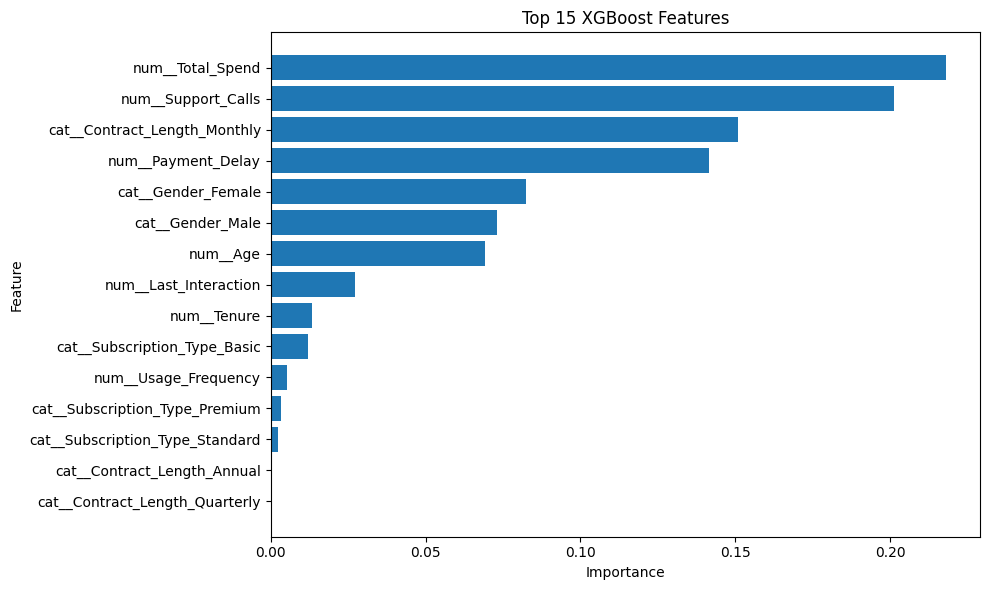


SAMPLE PREDICTIONS - Logistic Regression
 Age Gender  Tenure  Usage_Frequency  Support_Calls  Payment_Delay Subscription_Type Contract_Length  Total_Spend  Last_Interaction  Actual_Churn  Predicted_Churn  Churn_Probability Prediction
  22 Female      25               14              4             27             Basic         Monthly          598                 9             1                1             100.00        Yes
  41 Female      28               28              7             13          Standard         Monthly          584                20             0                1             100.00        Yes
  47   Male      27               10              2             29           Premium          Annual          757                21             0                1              66.97        Yes
  35   Male       9               12              5             17           Premium       Quarterly          232                18             0                1              98.62     

In [2]:
# ============================================================
# PROJECT 2: CUSTOMER CHURN PREDICTION
# Logistic Regression + Random Forest + XGBoost
# Kaggle Train/Test Dataset - Google Colab
# ============================================================

# ============================================================
# 1. INSTALL / IMPORT LIBRARIES
# ============================================================

!pip -q install xgboost

import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve
)


# ============================================================
# 2. UPLOAD TRAINING AND TESTING DATASET
# ============================================================

print("Please upload BOTH training and testing CSV files.")

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(" -", filename)


# ============================================================
# 3. FIND TRAINING AND TESTING FILES
# ============================================================

file_names = list(uploaded.keys())

train_file = None
test_file = None

for file in file_names:
    file_lower = file.lower()

    if "training" in file_lower or "train" in file_lower:
        train_file = file

    if "testing" in file_lower or "test" in file_lower:
        test_file = file

if train_file is None or test_file is None:
    raise FileNotFoundError(
        "Could not automatically identify training/testing files. "
        "Please upload files containing 'training'/'train' and 'testing'/'test' in their names."
    )

print("\nTraining file:", train_file)
print("Testing file :", test_file)


# ============================================================
# 4. LOAD DATASETS
# ============================================================

train_df = pd.read_csv(train_file)
test_df = pd.read_csv(test_file)

print("\nTraining Shape:", train_df.shape)
print("Testing Shape :", test_df.shape)

print("\nTraining Columns:")
print(train_df.columns.tolist())

print("\nTesting Columns:")
print(test_df.columns.tolist())


# ============================================================
# 5. CLEAN COLUMN NAMES
# ============================================================

train_df.columns = (
    train_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

test_df.columns = (
    test_df.columns
    .str.strip()
    .str.replace(" ", "_")
)

print("\nCleaned Columns:")
print(train_df.columns.tolist())


# ============================================================
# 6. CHECK TARGET COLUMN
# ============================================================

target_column = "Churn"

if target_column not in train_df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found in training dataset."
    )

if target_column not in test_df.columns:
    raise ValueError(
        f"Target column '{target_column}' was not found in testing dataset."
    )


# ============================================================
# 7. CHECK ORIGINAL TARGET DISTRIBUTION
# ============================================================

print("\nOriginal Training Target Distribution:")
print(train_df[target_column].value_counts(dropna=False))

print("\nOriginal Testing Target Distribution:")
print(test_df[target_column].value_counts(dropna=False))


# ============================================================
# 8. REMOVE ROWS WITH MISSING TARGET
# IMPORTANT:
# Do NOT convert missing target to 0.
# ============================================================

train_missing_target = train_df[target_column].isna().sum()
test_missing_target = test_df[target_column].isna().sum()

print("\nMissing target values:")
print("Training:", train_missing_target)
print("Testing :", test_missing_target)

train_df = train_df.dropna(
    subset=[target_column]
).reset_index(drop=True)

test_df = test_df.dropna(
    subset=[target_column]
).reset_index(drop=True)


# ============================================================
# 9. REMOVE DUPLICATES
# ============================================================

print("\nDuplicates before removal:")
print("Training:", train_df.duplicated().sum())
print("Testing :", test_df.duplicated().sum())

train_df = train_df.drop_duplicates().reset_index(drop=True)
test_df = test_df.drop_duplicates().reset_index(drop=True)

print("\nShapes after cleaning:")
print("Training:", train_df.shape)
print("Testing :", test_df.shape)


# ============================================================
# 10. SEPARATE FEATURES AND TARGET
# ============================================================

X_train = train_df.drop(columns=[target_column])
y_train = train_df[target_column].astype(int)

X_test = test_df.drop(columns=[target_column])
y_test = test_df[target_column].astype(int)


# ============================================================
# 11. REMOVE CUSTOMER ID
# CustomerID is an identifier, not a useful ML feature.
# ============================================================

id_columns = [
    "CustomerID",
    "Customer_ID",
    "customer_id",
    "ID",
    "Id"
]

for col in id_columns:
    if col in X_train.columns:
        X_train = X_train.drop(columns=[col])

    if col in X_test.columns:
        X_test = X_test.drop(columns=[col])


print("\nFeatures after removing ID:")
print(X_train.columns.tolist())


# ============================================================
# 12. ENSURE TRAINING AND TESTING HAVE SAME FEATURES
# ============================================================

common_columns = [
    col for col in X_train.columns
    if col in X_test.columns
]

X_train = X_train[common_columns]
X_test = X_test[common_columns]


# ============================================================
# 13. TARGET DISTRIBUTION
# ============================================================

print("\nFinal Training Target Distribution:")
print(y_train.value_counts())

print("\nFinal Testing Target Distribution:")
print(y_test.value_counts())

print("\nTraining Churn Percentage:")
print((y_train.value_counts(normalize=True) * 100).round(2))

print("\nTesting Churn Percentage:")
print((y_test.value_counts(normalize=True) * 100).round(2))


# ============================================================
# 14. IDENTIFY NUMERICAL AND CATEGORICAL FEATURES
# ============================================================

numeric_features = X_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_features = X_train.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\nNumerical Features:")
print(numeric_features)

print("\nCategorical Features:")
print(categorical_features)


# ============================================================
# 15. PREPROCESSING
# ============================================================

numeric_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)


categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            )
        )
    ]
)


preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            numeric_pipeline,
            numeric_features
        ),
        (
            "cat",
            categorical_pipeline,
            categorical_features
        )
    ],
    remainder="drop"
)


# ============================================================
# 16. DEFINE MODELS
# ============================================================

logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)


random_forest_model = RandomForestClassifier(
    n_estimators=150,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)


xgboost_model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)


# ============================================================
# 17. CREATE PIPELINES
# ============================================================

models = {

    "Logistic Regression": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", logistic_model)
        ]
    ),

    "Random Forest": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", random_forest_model)
        ]
    ),

    "XGBoost": Pipeline(
        steps=[
            ("preprocessor", preprocessor),
            ("model", xgboost_model)
        ]
    )
}


# ============================================================
# 18. TRAIN AND EVALUATE ALL MODELS
# ============================================================

results = []

predictions = {}
probabilities = {}

print("\n" + "=" * 70)
print("MODEL TRAINING")
print("=" * 70)

for name, model in models.items():

    print("\nTraining:", name)

    # Train
    model.fit(X_train, y_train)

    # Predictions
    y_pred = model.predict(X_test)

    # Probability of Churn = 1
    y_prob = model.predict_proba(X_test)[:, 1]

    predictions[name] = y_pred
    probabilities[name] = y_prob

    # Metrics
    accuracy = accuracy_score(y_test, y_pred)

    precision = precision_score(
        y_test,
        y_pred,
        zero_division=0
    )

    recall = recall_score(
        y_test,
        y_pred,
        zero_division=0
    )

    f1 = f1_score(
        y_test,
        y_pred,
        zero_division=0
    )

    roc_auc = roc_auc_score(
        y_test,
        y_prob
    )

    results.append({
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1,
        "ROC-AUC": roc_auc
    })

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            y_pred,
            target_names=["No Churn", "Churn"],
            zero_division=0
        )
    )


# ============================================================
# 19. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)

print(
    results_df.round(4).to_string(index=False)
)


# ============================================================
# 20. BEST MODELS
# ============================================================

best_f1_model = results_df.loc[
    results_df["F1 Score"].idxmax(),
    "Model"
]

best_auc_model = results_df.loc[
    results_df["ROC-AUC"].idxmax(),
    "Model"
]

best_accuracy_model = results_df.loc[
    results_df["Accuracy"].idxmax(),
    "Model"
]

print("\n" + "=" * 70)
print("BEST MODELS")
print("=" * 70)

print("Best based on Accuracy :", best_accuracy_model)
print("Best based on F1 Score :", best_f1_model)
print("Best based on ROC-AUC  :", best_auc_model)


# ============================================================
# 21. CONFUSION MATRICES
# ============================================================

for name in models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[name]
    )

    print("\n" + "=" * 70)
    print(name)
    print("=" * 70)

    print("Confusion Matrix:")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot()
    plt.title(f"Confusion Matrix - {name}")
    plt.show()


# ============================================================
# 22. ROC CURVES
# ============================================================

plt.figure(figsize=(9, 6))

for name in models.keys():

    fpr, tpr, thresholds = roc_curve(
        y_test,
        probabilities[name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[name]
    )

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Customer Churn Prediction")
plt.legend()
plt.grid()
plt.show()


# ============================================================
# 23. FEATURE IMPORTANCE
# RANDOM FOREST
# ============================================================

rf_pipeline = models["Random Forest"]

rf_preprocessor = rf_pipeline.named_steps["preprocessor"]
rf_model = rf_pipeline.named_steps["model"]

feature_names = rf_preprocessor.get_feature_names_out()

rf_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": rf_model.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 15 RANDOM FOREST FEATURES")
print("=" * 70)

print(
    rf_importance.head(15).to_string(index=False)
)


plt.figure(figsize=(10, 6))

plt.barh(
    rf_importance.head(15)["Feature"][::-1],
    rf_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 Random Forest Features")
plt.tight_layout()
plt.show()


# ============================================================
# 24. FEATURE IMPORTANCE
# XGBOOST
# ============================================================

xgb_pipeline = models["XGBoost"]

xgb_preprocessor = xgb_pipeline.named_steps["preprocessor"]
xgb_model = xgb_pipeline.named_steps["model"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

xgb_importance = pd.DataFrame({
    "Feature": xgb_feature_names,
    "Importance": xgb_model.feature_importances_
})

xgb_importance = xgb_importance.sort_values(
    by="Importance",
    ascending=False
)

print("\n" + "=" * 70)
print("TOP 15 XGBOOST FEATURES")
print("=" * 70)

print(
    xgb_importance.head(15).to_string(index=False)
)


plt.figure(figsize=(10, 6))

plt.barh(
    xgb_importance.head(15)["Feature"][::-1],
    xgb_importance.head(15)["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 15 XGBoost Features")
plt.tight_layout()
plt.show()


# ============================================================
# 25. SAMPLE CUSTOMER CHURN PREDICTIONS
# ============================================================

best_model = models[best_f1_model]

sample_data = X_test.head(10).copy()

sample_predictions = best_model.predict(sample_data)
sample_probabilities = best_model.predict_proba(sample_data)[:, 1]

prediction_df = sample_data.copy()

prediction_df["Actual_Churn"] = y_test.head(10).values

prediction_df["Predicted_Churn"] = sample_predictions

prediction_df["Churn_Probability"] = (
    sample_probabilities * 100
).round(2)

prediction_df["Prediction"] = np.where(
    sample_predictions == 1,
    "Yes",
    "No"
)

print("\n" + "=" * 70)
print(f"SAMPLE PREDICTIONS - {best_f1_model}")
print("=" * 70)

print(
    prediction_df.to_string(index=False)
)


# ============================================================
# 26. SAVE MODEL COMPARISON
# ============================================================

results_df.to_csv(
    "customer_churn_model_comparison.csv",
    index=False
)

prediction_df.to_csv(
    "customer_churn_sample_predictions.csv",
    index=False
)

print("\nFiles saved:")
print("1. customer_churn_model_comparison.csv")
print("2. customer_churn_sample_predictions.csv")


# ============================================================
# 27. FINAL SUMMARY
# ============================================================

print("\n" + "=" * 70)
print("PROJECT COMPLETED SUCCESSFULLY")
print("=" * 70)

print("\nModels implemented:")
print("1. Logistic Regression")
print("2. Random Forest")
print("3. XGBoost")

print("\nBest model based on F1 Score:")
print(best_f1_model)

print("\nBest model based on ROC-AUC:")
print(best_auc_model)

print("\nBest model based on Accuracy:")
print(best_accuracy_model)

print("\nCustomer Churn Prediction project completed.")